# Preprocess SSP Population and GDP Inputs

Resamples SSP population and GDP files to the 0.1 degree reference grid and normalizes
using the exact same scalars as the training data (saved in NORM_STATS_TRAIN.json by fix_data_pop_gdp.ipynb).

In [40]:
import os
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform


## 1. Reference grid

In [41]:
OUTPUT_DIR        = r'READY_data\inputs_normalized\ssp'   # normalized model-ready outputs
GDP_CONVERTED_DIR = r'READY_data\inputs_converted\ssp'    # unit-converted GDP (not normalized)
REFERENCE         = r'READY_data\labels\2024_CISI_010deg_nearest.tif'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(GDP_CONVERTED_DIR, exist_ok=True)

with rasterio.open(REFERENCE) as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_width     = ref.width
    ref_height    = ref.height
    ref_profile   = ref.profile.copy()

with rasterio.open(r'READY_data\labels\eu_mask_010deg.tif') as src:
    eu27_mask = (src.read(1).astype(np.float32) > 0)

print(f'Reference grid: {ref_height}x{ref_width}, res={round(abs(ref_transform[0]), 4)} deg')
print(f'EU27 mask: {eu27_mask.sum():,} valid pixels')
print(f'Normalized outputs  → {OUTPUT_DIR}')
print(f'GDP converted files → {GDP_CONVERTED_DIR}')

Reference grid: 485x570, res=0.1 deg
EU27 mask: 53,726 valid pixels
Normalized outputs  → READY_data\inputs_normalized\ssp
GDP converted files → READY_data\inputs_converted\ssp


## 2. Functions

In [42]:
RESAMPLE_METHOD = {'gdp': Resampling.average, 'pop': Resampling.sum}

TRAIN_RAW = {
    'gdp': r'READY_data/inputs/2019_gdp_aligned_010.tif',
    'pop': r'READY_data/inputs/2020_pop_aligned_010.tif',
}

NORM_STATS_TRAIN_PATH = r'READY_data/inputs_normalized/NORM_STATS_TRAIN.json'


def resample_only(input_path, kind):
    data = np.full((ref_height, ref_width), np.nan, dtype=np.float32)
    with rasterio.open(input_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=RESAMPLE_METHOD[kind],
        )
    for flag in [-3.4028235e+38, -3.402823e+38, -99999, -9999, -32768]:
        data[np.isclose(data, flag, rtol=1e-5)] = np.nan
    data[data < -1e10] = np.nan
    data[np.isinf(data)] = np.nan
    data[data < 0] = np.nan
    return data


def load_training_stats(kind):
    """Load log1p mean/std from NORM_STATS_TRAIN.json (written by fix_data_pop_gdp.ipynb)."""
    with open(NORM_STATS_TRAIN_PATH) as f:
        stats = json.load(f)
    mean_val = stats[kind]['train_mean']
    std_val  = stats[kind]['train_std']
    data     = resample_only(TRAIN_RAW[kind], kind)
    max_val  = float(data[~np.isnan(data)].max())
    print('Training stats for ' + kind.upper() + ': mean=' + str(round(mean_val, 4))
          + '  std=' + str(round(std_val, 4)) + '  raw_max=' + str(round(max_val, 2)))
    return mean_val, std_val, max_val


def compute_unit_scale(file_dict, kind, train_log1p_mean):
    """Compute multiplicative scale to convert SSP values into training units."""
    n = sum(len(v) for v in file_dict.values())
    print('Computing unit scale for ' + kind.upper() + ' across ' + str(n) + ' files...')
    all_log_vals = []
    for ssp, years in file_dict.items():
        for year, path in years.items():
            d = resample_only(path, kind)
            valid = d[~np.isnan(d)]
            if len(valid):
                all_log_vals.append(np.log1p(valid))
    combined = np.concatenate(all_log_vals)
    ssp_mean = float(combined.mean())
    scale    = float(np.exp(train_log1p_mean - ssp_mean))
    print('  SSP log1p mean=' + str(round(ssp_mean, 4))
          + '  train log1p mean=' + str(round(train_log1p_mean, 4))
          + '  scale=' + str(round(scale, 6)))
    return scale


def normalize_and_save(input_path, output_path, kind, train_mean, train_std,
                        unit_scale=1.0, train_max=None):
    data = resample_only(input_path, kind)
    if unit_scale != 1.0:
        data = data * unit_scale
    if train_max is not None:
        data = np.where(~np.isnan(data), np.minimum(data, train_max), data)
    valid = ~np.isnan(data)
    if valid.sum() == 0:
        print('  WARNING: no valid data in ' + os.path.basename(input_path))
        return
    normalized = np.full_like(data, np.nan)
    normalized[valid] = (np.log1p(data[valid]) - train_mean) / (train_std + 1e-8)
    print('  ' + os.path.basename(input_path)
          + '  mean=' + str(round(float(np.nanmean(normalized)), 4))
          + '  range=[' + str(round(float(np.nanmin(normalized)), 3))
          + ', ' + str(round(float(np.nanmax(normalized)), 3)) + ']')
    profile = ref_profile.copy()
    profile.update(dtype='float32', count=1, nodata=np.nan)
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(normalized[np.newaxis, :, :])


print('Functions loaded.')


Functions loaded.


## 3. Process population files (15 files)

In [43]:
# # --- POP unit check: training vs SSP raw values at 0.1° ---
# # Both should be people-per-pixel (total headcount per 0.1° cell).
# # Training: WorldPop 2020 already at 0.1° (sum-aggregated upstream).
# # SSP: IIASA gridded pop at 0.00833°, resampled here with Resampling.sum → same meaning.

# with rasterio.open(TRAIN_RAW['pop']) as src:
#     train_pop = src.read(1).astype(np.float32)
# train_pop[~np.isfinite(train_pop)] = np.nan
# train_pop[train_pop < 0] = np.nan
# tp = train_pop[np.isfinite(train_pop)]

# # Resample one SSP POP file to 0.1° with sum to compare
# ssp_check = np.full((ref_height, ref_width), np.nan, dtype=np.float32)
# with rasterio.open(r'READY_data\SSP1\SSP1_2030_EU_UK_POP_01.tif') as src:
#     reproject(source=rasterio.band(src, 1), destination=ssp_check,
#               dst_transform=ref_transform, dst_crs=ref_crs,
#               resampling=Resampling.sum)
# ssp_check[~np.isfinite(ssp_check)] = np.nan
# ssp_check[ssp_check < 0] = np.nan
# sp = ssp_check[np.isfinite(ssp_check)]

# print('=== POP UNIT CHECK (raw people per 0.1° pixel) ===')
# print(f'{"":30} {"Train 2020":>14} {"SSP1 2030":>14}')
# print('-' * 60)
# for label, tv, sv in [
#     ('Min',    tp.min(),               sp.min()),
#     ('p1',     np.percentile(tp, 1),   np.percentile(sp, 1)),
#     ('Median', np.median(tp),          np.median(sp)),
#     ('p95',    np.percentile(tp, 95),  np.percentile(sp, 95)),
#     ('Max',    tp.max(),               sp.max()),
#     ('Mean',   tp.mean(),              sp.mean()),
# ]:
#     print(f'  {label:<28} {tv:>14,.0f} {sv:>14,.0f}')

# ratio = tp.mean() / sp.mean()
# print(f'\n  Mean ratio (train/SSP): {ratio:.3f}  — values of 1 confirm same unit.')
# if 0.5 < ratio < 2.0:
#     print('  UNIT CHECK PASSED: distributions are consistent (people per pixel).')
# else:
#     print(f'  WARNING: ratio={ratio:.2f} suggests a unit mismatch — investigate before proceeding.')


In [44]:
POP_FILES = {
    'SSP1': {2030: r'READY_data\SSP1\SSP1_2030_EU_UK_POP_01.tif',
             2050: r'READY_data\SSP1\SSP1_2050_EU_UK_POP_01.tif',
             2100: r'READY_data\SSP1\SSP1_2100_EU_UK_POP_01.tif'},
    'SSP2': {2030: r'READY_data\SSP2\SSP2_2030_EU_UK_POP_01.tif',
             2050: r'READY_data\SSP2\SSP2_2050_EU_UK_POP_01.tif',
             2100: r'READY_data\SSP2\SSP2_2100_EU_UK_POP_01.tif'},
    'SSP3': {2030: r'READY_data\SSP3\SSP3_2030_EU_UK_POP_01.tif',
             2050: r'READY_data\SSP3\SSP3_2050_EU_UK_POP_01.tif',
             2100: r'READY_data\SSP3\SSP3_2100_EU_UK_POP_01.tif'},
    'SSP4': {2030: r'READY_data\SSP4\SSP4_2030_EU_UK_POP_01.tif',
             2050: r'READY_data\SSP4\SSP4_2050_EU_UK_POP_01.tif',
             2100: r'READY_data\SSP4\SSP4_2100_EU_UK_POP_01.tif'},
    'SSP5': {2030: r'READY_data\SSP5\SSP5_2030_EU_UK_POP_01.tif',
             2050: r'READY_data\SSP5\SSP5_2050_EU_UK_POP_01.tif',
             2100: r'READY_data\SSP5\SSP5_2100_EU_UK_POP_01.tif'},
}

pop_train_mean, pop_train_std, pop_train_max = load_training_stats('pop')


Training stats for POP: mean=6.1368  std=3.0314  raw_max=3436316.25


## 4. Resolution check

In [45]:
_NORM_DIR = r'READY_data\inputs_normalized\ssp'
_SSPS  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
_YEARS = [2030, 2050, 2100]

# --- Raw input resolution check ---
print('=== RAW INPUT RESOLUTIONS ===')
raw_files = {
    'CISI label (target)':     r'READY_data\labels\2024_CISI_010deg_nearest.tif',
    'GDP training (2019)':     r'READY_data\inputs\2019_gdp_aligned_010.tif',
    'Pop training (2020)':     r'READY_data\inputs\2020_pop_aligned_010.tif',
    'Land cover (2020)':       r'READY_data\landuse_onehot\clipped_history_2020_onehot.tif',
    'Pop SSP raw (SSP1 2030)': r'READY_data\SSP1\SSP1_2030_EU_UK_POP_01.tif',
}
print(f'  {"File":<35} {"Shape":>12} {"Res (°)":>10}  {"0.1° match?"}')
print('  ' + '-' * 75)
for label, path in raw_files.items():
    if not os.path.exists(path):
        print(f'  {label:<35} FILE NOT FOUND')
        continue
    with rasterio.open(path) as src:
        res_x = abs(src.transform[0])
        shape = f'{src.height}x{src.width}'
    ok = 'OK' if abs(res_x - 0.1) < 0.001 else f'will be resampled ({res_x:.5f}°)'
    print(f'  {label:<35} {shape:>12} {res_x:>10.5f}  {ok}')

# --- POP normalized output files (15 files, created in section 3) ---
print('\n=== POP NORMALIZED OUTPUT FILES (15) ===')
print(f'  {"File":<40} {"Shape":>12} {"Res (°)":>10}  {"Status"}')
print('  ' + '-' * 75)

all_ok = True
for ssp in _SSPS:
    for year in _YEARS:
        fname = f'POP_{ssp}_{year}_normalized.tif'
        path  = os.path.join(_NORM_DIR, fname)
        if not os.path.exists(path):
            print(f'  {fname:<40} MISSING')
            all_ok = False
            continue
        with rasterio.open(path) as src:
            res_x = abs(src.transform[0])
            shape = f'{src.height}x{src.width}'
        ok = 'OK' if abs(res_x - 0.1) < 0.001 else f'wrong res: {res_x:.5f}°'
        if abs(res_x - 0.1) >= 0.001:
            all_ok = False
        print(f'  {fname:<40} {shape:>12} {res_x:>10.5f}  {ok}')

print()
print('All 15 POP files present and at 0.1°.' if all_ok else 'WARNING: some POP files are missing or at wrong resolution.')
print('GDP converted files are created in section 5, verified in section 6.')

=== RAW INPUT RESOLUTIONS ===
  File                                       Shape    Res (°)  0.1° match?
  ---------------------------------------------------------------------------
  CISI label (target)                      485x570    0.10000  OK
  GDP training (2019)                      485x570    0.10000  OK
  Pop training (2020)                      485x570    0.10000  OK
  Land cover (2020)                        485x570    0.10000  OK
  Pop SSP raw (SSP1 2030)                4554x8480    0.00833  will be resampled (0.00833°)

=== POP NORMALIZED OUTPUT FILES (15) ===
  File                                            Shape    Res (°)  Status
  ---------------------------------------------------------------------------
  POP_SSP1_2030_normalized.tif                  485x570    0.10000  OK
  POP_SSP1_2050_normalized.tif                  485x570    0.10000  OK
  POP_SSP1_2100_normalized.tif                  485x570    0.10000  OK
  POP_SSP2_2030_normalized.tif                  485x5

## 5. Process GDP files — unit conversion

**Training GDP (Chen et al. 2022):** 1 km × 1 km total GDP, millions of 2017 USD per pixel — resampled to 0.1° with sum.

**SSP GDP (Wang & Sun 2022):** total GDP at 30 arc-seconds, 2005 PPP USD per pixel — resampled to 0.1° with sum.

**Fix:** multiply Wang & Sun values by `1.28e-6` to convert 2005 PPP USD → millions of 2017 USD (÷ 1,000,000 for scale; × 1.28 for GDP deflator 2005→2017). No per-capita division — both datasets are total GDP per pixel, consistent with training. Saved as `GDP_{ssp}_{year}_converted.tif`.

In [46]:
GDP_FILES = {
    'SSP1': {2030: r'READY_data\GDP SSP\GDP2030_ssp1.tif',
             2050: r'READY_data\GDP SSP\GDP2050_ssp1.tif',
             2100: r'READY_data\GDP SSP\GDP2100_ssp1.tif'},
    'SSP2': {2030: r'READY_data\GDP SSP\GDP2030_ssp2.tif',
             2050: r'READY_data\GDP SSP\GDP2050_ssp2.tif',
             2100: r'READY_data\GDP SSP\GDP2100_ssp2.tif'},
    'SSP3': {2030: r'READY_data\GDP SSP\GDP2030_ssp3.tif',
             2050: r'READY_data\GDP SSP\GDP2050_ssp3.tif',
             2100: r'READY_data\GDP SSP\GDP2100_ssp3.tif'},
    'SSP4': {2030: r'READY_data\GDP SSP\GDP2030_ssp4.tif',
             2050: r'READY_data\GDP SSP\GDP2050_ssp4.tif',
             2100: r'READY_data\GDP SSP\GDP2100_ssp4.tif'},
    'SSP5': {2030: r'READY_data\GDP SSP\GDP2030_ssp5.tif',
             2050: r'READY_data\GDP SSP\GDP2050_ssp5.tif',
             2100: r'READY_data\GDP SSP\GDP2100_ssp5.tif'},
}
print('GDP_FILES defined.')


GDP_FILES defined.


In [47]:
# 2005 PPP USD → millions of 2017 USD: divide by 1e6 (scale), multiply by 1.28 (GDP deflator 2005→2017)
UNIT_SCALE = 1.28e-6

print('Unit conversion: Wang & Sun 2005 PPP USD → millions of 2017 USD (scale = 1.28e-6)')
print(f'{"File":<30} {"min":>10} {"median":>10} {"max":>12}')
print('-' * 65)

profile = ref_profile.copy()
profile.update(dtype='float32', count=1, nodata=float('nan'))

gdp_converted = {}

for ssp, years in GDP_FILES.items():
    gdp_converted[ssp] = {}
    for year, gdp_path in years.items():
        out_path = os.path.join(GDP_CONVERTED_DIR, f'GDP_{ssp}_{year}_converted.tif')

        gdp_total = np.full((ref_height, ref_width), np.nan, dtype=np.float32)
        with rasterio.open(gdp_path) as src:
            reproject(source=rasterio.band(src, 1), destination=gdp_total,
                      dst_transform=ref_transform, dst_crs=ref_crs,
                      resampling=Resampling.sum)
        for flag in [-3.4028235e+38, -3.402823e+38, -99999, -9999, -32768]:
            gdp_total[np.isclose(gdp_total, flag, rtol=1e-5)] = np.nan
        gdp_total[~np.isfinite(gdp_total)] = np.nan
        gdp_total[gdp_total < 0] = np.nan

        converted = np.where(np.isfinite(gdp_total), gdp_total * UNIT_SCALE, np.nan)
        converted[~eu27_mask] = np.nan

        gdp_converted[ssp][year] = converted

        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(converted[np.newaxis])

        v = converted[np.isfinite(converted)]
        print(f'{os.path.basename(gdp_path):<30} {v.min():>10.4f} {np.median(v):>10.4f} {v.max():>12.4f}')

print('\nConverted files saved to', GDP_CONVERTED_DIR)

Unit conversion: Wang & Sun 2005 PPP USD → millions of 2017 USD (scale = 1.28e-6)
File                                  min     median          max
-----------------------------------------------------------------
GDP2030_ssp1.tif                   0.0000     7.6366  241154.1562
GDP2050_ssp1.tif                   0.0000     9.9388  369512.1875
GDP2100_ssp1.tif                   0.0000    13.3097  723919.5000
GDP2030_ssp2.tif                   0.0000     7.7242  233902.8750
GDP2050_ssp2.tif                   0.0000     9.7052  332137.5000
GDP2100_ssp2.tif                   0.0000    14.5736  655179.2500
GDP2030_ssp3.tif                   0.0000     7.5615  219570.1719
GDP2050_ssp3.tif                   0.0000     8.1521  261873.1562
GDP2100_ssp3.tif                   0.0000     8.1116  294707.5312
GDP2030_ssp4.tif                   0.0000     7.6045  236133.9688
GDP2050_ssp4.tif                   0.0000     9.4156  348923.5312
GDP2100_ssp4.tif                   0.0000    11.6756  619325

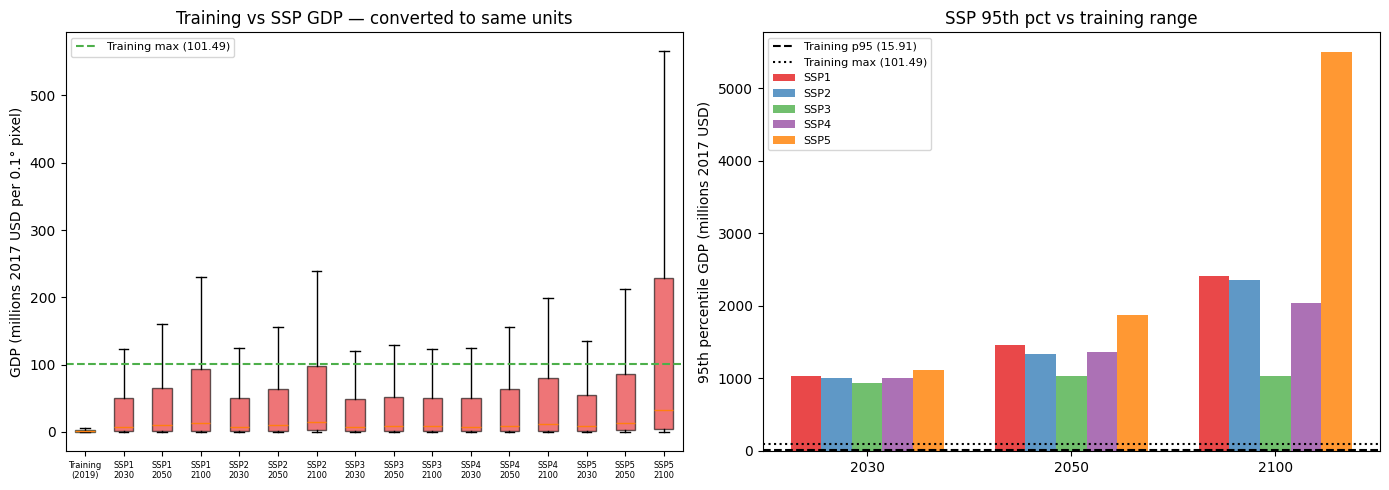

Training GDP — min: 0.0000  max: 101.4927  p95: 15.9073  p99: 40.2393
SSP1 2030 — min: 0.0000  median: 7.6366  p95: 1028.30  p99: 7784.78  max: 241154.1562
SSP1 2050 — min: 0.0000  median: 9.9388  p95: 1459.55  p99: 11358.67  max: 369512.1875
SSP1 2100 — min: 0.0000  median: 13.3097  p95: 2407.50  p99: 18986.53  max: 723919.5000
SSP2 2030 — min: 0.0000  median: 7.7242  p95: 1001.92  p99: 7550.14  max: 233902.8750
SSP2 2050 — min: 0.0000  median: 9.7052  p95: 1335.34  p99: 10249.55  max: 332137.5000
SSP2 2100 — min: 0.0000  median: 14.5736  p95: 2355.42  p99: 18463.23  max: 655179.2500
SSP3 2030 — min: 0.0000  median: 7.5615  p95: 934.50  p99: 6989.73  max: 219570.1719
SSP3 2050 — min: 0.0000  median: 8.1521  p95: 1033.26  p99: 7731.60  max: 261873.1562
SSP3 2100 — min: 0.0000  median: 8.1116  p95: 1032.32  p99: 7773.57  max: 294707.5312
SSP4 2030 — min: 0.0000  median: 7.6045  p95: 1008.43  p99: 7622.36  max: 236133.9688
SSP4 2050 — min: 0.0000  median: 9.4156  p95: 1358.13  p99: 10483

In [48]:
# Compare training GDP (raw, millions 2017 USD) vs SSP converted GDP (same units)
train_gdp_raw = resample_only(TRAIN_RAW['gdp'], 'gdp')
train_gdp_raw[train_gdp_raw <= 0] = np.nan
train_gdp_vals = train_gdp_raw[np.isfinite(train_gdp_raw)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
labels = ['Training\n(2019)']
data_boxes = [train_gdp_vals]
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        labels.append(f'{ssp}\n{year}')
        v = gdp_converted[ssp][year]
        data_boxes.append(v[np.isfinite(v)])

bp = ax.boxplot(data_boxes, patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#4daf4a' if i == 0 else '#e41a1c')
    patch.set_alpha(0.6)

train_max = float(train_gdp_vals.max())
ax.axhline(train_max, color='#4daf4a', linestyle='--', linewidth=1.5,
           label=f'Training max ({train_max:.2f})')
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=6)
ax.set_ylabel('GDP (millions 2017 USD per 0.1° pixel)')
ax.set_title('Training vs SSP GDP — converted to same units')
ax.legend(fontsize=8)

ax = axes[1]
train_p95 = float(np.percentile(train_gdp_vals, 95))
x = np.arange(3)
width = 0.15
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for i, ssp in enumerate(['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']):
    p95s = [float(np.percentile(gdp_converted[ssp][y][np.isfinite(gdp_converted[ssp][y])], 95))
            for y in [2030, 2050, 2100]]
    ax.bar(x + i * width, p95s, width, label=ssp, color=colors[i], alpha=0.8)

ax.axhline(train_p95, color='black', linestyle='--', linewidth=1.5,
           label=f'Training p95 ({train_p95:.2f})')
ax.axhline(train_max, color='black', linestyle=':', linewidth=1.5,
           label=f'Training max ({train_max:.2f})')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([2030, 2050, 2100])
ax.set_ylabel('95th percentile GDP (millions 2017 USD)')
ax.set_title('SSP 95th pct vs training range')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Training GDP — min: {train_gdp_vals.min():.4f}  max: {train_max:.4f}  p95: {train_p95:.4f}  p99: {np.percentile(train_gdp_vals, 99):.4f}')
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        v = gdp_converted[ssp][year]
        v = v[np.isfinite(v)]
        print(f'{ssp} {year} — min: {v.min():.4f}  median: {np.median(v):.4f}  p95: {np.percentile(v, 95):.2f}  p99: {np.percentile(v, 99):.2f}  max: {v.max():.4f}')

In [49]:
import numpy as np
import rasterio
import os

_DIR = r'READY_data\inputs_converted\ssp'

print(f'{"File":<25} {"p99":>10} {"p99.9":>10} {"p99.99":>10} {"max":>12}  train_max=91.44')
print('-' * 80)
for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        path = os.path.join(_DIR, f'GDP_{ssp}_{year}_converted.tif')
        if not os.path.exists(path):
            print(f'{ssp} {year:<20} FILE NOT FOUND')
            continue
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float32)
        v = data[np.isfinite(data)]
        p99, p999, p9999 = np.percentile(v, [99, 99.9, 99.99])
        print(f'{ssp} {year:<20} {p99:>10.2f} {p999:>10.2f} {p9999:>10.2f} {v.max():>12.2f}')

File                             p99      p99.9     p99.99          max  train_max=91.44
--------------------------------------------------------------------------------
SSP1 2030                    7784.78   40970.32  106773.59    241154.16
SSP1 2050                   11358.67   57639.59  153795.39    369512.19
SSP1 2100                   18986.53  102295.99  283878.22    723919.50
SSP2 2030                    7550.14   39111.42  101827.08    233902.88
SSP2 2050                   10249.55   52314.46  137775.06    332137.50
SSP2 2100                   18463.23   98559.71  265555.43    655179.25
SSP3 2030                    6989.73   36038.51   93720.22    219570.17
SSP3 2050                    7731.60   40140.75  105417.30    261873.16
SSP3 2100                    7773.57   40208.58  112730.60    294707.53
SSP4 2030                    7622.36   39881.71  102756.74    236133.97
SSP4 2050                   10483.56   53986.70  142071.55    348923.53
SSP4 2100                   16007.73  

## 6. Verify GDP outputs

In [50]:
_NORM_DIR = r'READY_data\inputs_normalized\ssp'
_SSPS  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']
_YEARS = [2030, 2050, 2100]

print(f'{"File":<35} {"Shape":>12} {"Valid px":>10} {"Min":>8} {"Max":>8} {"Mean":>8}  {"OK?"}')
print('-' * 100)

all_ok = True
for ssp in _SSPS:
    for year in _YEARS:
        fname = f'GDP_{ssp}_{year}_normalized.tif'
        path  = os.path.join(_NORM_DIR, fname)
        if not os.path.exists(path):
            print(f'{fname:<35} MISSING')
            all_ok = False
            continue
        with rasterio.open(path) as src:
            data  = src.read(1).astype(np.float32)
            res_x = abs(src.transform[0])
            shape = f'{src.height}x{src.width}'
        valid = ~np.isnan(data)
        res_ok    = abs(res_x - 0.1) < 0.001
        has_data  = valid.sum() > 0
        no_extremes = np.all(np.abs(data[valid]) < 20) if has_data else False
        ok = 'OK' if (res_ok and has_data and no_extremes) else 'FAIL'
        if not (res_ok and has_data and no_extremes):
            all_ok = False
        print(f'{fname:<35} {shape:>12} {valid.sum():>10,} {np.nanmin(data):>8.3f} {np.nanmax(data):>8.3f} {np.nanmean(data):>8.4f}  {ok}')

print()
print('All GDP files OK.' if all_ok else 'WARNING: one or more GDP files have issues.')

File                                       Shape   Valid px      Min      Max     Mean  OK?
----------------------------------------------------------------------------------------------------
GDP_SSP1_2030_normalized.tif             485x570     50,785   -1.041    4.064   1.6648  OK
GDP_SSP1_2050_normalized.tif             485x570     50,785   -1.041    4.064   1.8231  OK
GDP_SSP1_2100_normalized.tif             485x570     50,771   -1.040    4.064   2.0019  OK
GDP_SSP2_2030_normalized.tif             485x570     50,785   -1.041    4.064   1.6740  OK
GDP_SSP2_2050_normalized.tif             485x570     50,785   -1.041    4.064   1.8124  OK
GDP_SSP2_2100_normalized.tif             485x570     50,771   -1.040    4.064   2.0646  OK
GDP_SSP3_2030_normalized.tif             485x570     50,785   -1.041    4.064   1.6585  OK
GDP_SSP3_2050_normalized.tif             485x570     50,771   -1.041    4.064   1.7052  OK
GDP_SSP3_2100_normalized.tif             485x570     50,652   -1.041    4.064  

In [51]:
_DIR = r'READY_data\inputs_converted\ssp'
train_max = 101.49

path = os.path.join(_DIR, 'GDP_SSP1_2030_converted.tif')
with rasterio.open(path) as src:
    data = src.read(1).astype(np.float32)
data[~eu27_mask] = np.nan
v = data[np.isfinite(data) & (data > 0)]
total = len(v)

print(f'Total valid pixels (EU27 incl. Italy): {total:,}  (training max = {train_max})')
print(f'{"Ceiling":<12} {"Clipped px":>12} {"Clipped %":>10}')
print('-' * 38)
for ceiling in [101, 200, 500, 1000, 5000, 10000, 50000]:
    clipped = int(np.sum(v > ceiling))
    print(f'{ceiling:<12} {clipped:>12,} {100*clipped/total:>9.2f}%')

Total valid pixels (EU27 incl. Italy): 50,785  (training max = 101.49)
Ceiling        Clipped px  Clipped %
--------------------------------------
101                 9,484     18.67%
200                 6,834     13.46%
500                 4,109      8.09%
1000                2,737      5.39%
5000                  806      1.59%
10000                 406      0.80%
50000                  37      0.07%


# 7. GDP normalization

Training GDP — floor: 0.0500  ceiling: 100.5842  log1p_mean: 0.9421  log1p_std: 0.9051
Pixels below floor  (SSP1 2030): 3.2%
Pixels above ceiling (SSP1 2030): 18.7%
Training normalized  — min: -0.987  max: 3.960  mean: -0.000
SSP1 2030 normalized — min: -0.987  max: 4.064  mean: 1.666


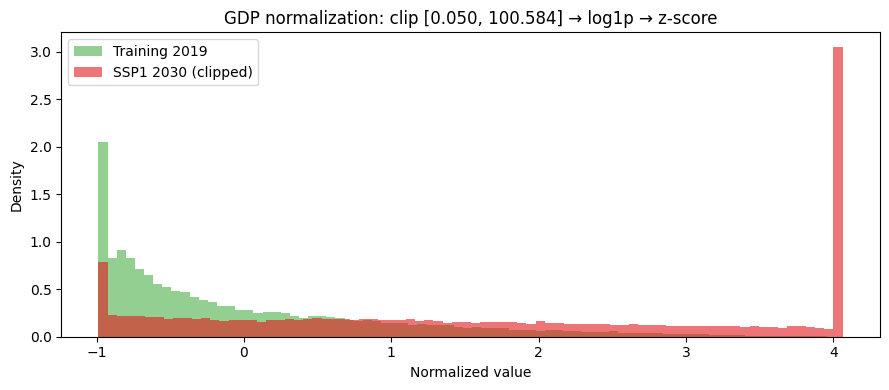

In [57]:
import numpy as np
import rasterio
import os
import matplotlib.pyplot as plt

_DIR = r'READY_data\inputs_converted\ssp'

# ── Training GDP stats ────────────────────────────────────────────────────────
with rasterio.open(r'READY_data\labels\eu_mask_010deg_ex_italy.tif') as src:
    eu_exitaly = (src.read(1).astype(np.float32) > 0)
with rasterio.open(r'READY_data\inputs\2019_gdp_aligned_010.tif') as src:
    train_raw = src.read(1).astype(np.float32)
train_raw[~np.isfinite(train_raw)] = np.nan
train_raw[train_raw <= 0] = np.nan
train_raw[~eu_exitaly]    = np.nan
t = train_raw[np.isfinite(train_raw)]

# Ceiling = 1.1× training max (10% headroom), Floor = training min
# Both clip SSP values to the range the model was trained on.
GDP_CEILING  = 1.1 * float(t.max())
GDP_FLOOR    = float(t.min())
GDP_LOG_MEAN = float(np.log1p(t).mean())
GDP_LOG_STD  = float(np.log1p(t).std())

print(f'Training GDP — floor: {GDP_FLOOR:.4f}  ceiling: {GDP_CEILING:.4f}  log1p_mean: {GDP_LOG_MEAN:.4f}  log1p_std: {GDP_LOG_STD:.4f}')

# ── Verify on SSP1 2030 ───────────────────────────────────────────────────────
with rasterio.open(os.path.join(_DIR, 'GDP_SSP1_2030_converted.tif')) as src:
    ssp_raw = src.read(1).astype(np.float32)
ssp_raw[~eu27_mask] = np.nan
s = ssp_raw[np.isfinite(ssp_raw) & (ssp_raw > 0)]
s_clipped = np.clip(s, GDP_FLOOR, GDP_CEILING)

s_norm = (np.log1p(s_clipped) - GDP_LOG_MEAN) / GDP_LOG_STD
t_norm = (np.log1p(t) - GDP_LOG_MEAN) / GDP_LOG_STD

print(f'Pixels below floor  (SSP1 2030): {100*np.mean(s < GDP_FLOOR):.1f}%')
print(f'Pixels above ceiling (SSP1 2030): {100*np.mean(s > GDP_CEILING):.1f}%')
print(f'Training normalized  — min: {t_norm.min():.3f}  max: {t_norm.max():.3f}  mean: {t_norm.mean():.3f}')
print(f'SSP1 2030 normalized — min: {s_norm.min():.3f}  max: {s_norm.max():.3f}  mean: {s_norm.mean():.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(t_norm, bins=80, alpha=0.6, color='#4daf4a', density=True, label='Training 2019')
ax.hist(s_norm, bins=80, alpha=0.6, color='#e41a1c', density=True, label='SSP1 2030 (clipped)')
ax.set_title(f'GDP normalization: clip [{GDP_FLOOR:.3f}, {GDP_CEILING:.3f}] → log1p → z-score')
ax.set_xlabel('Normalized value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
# Save 15 GDP normalized files to inputs_normalized/ssp/
# Normalization: clip to [GDP_FLOOR, GDP_CEILING] → log1p → z-score

profile = ref_profile.copy()
profile.update(dtype='float32', count=1, nodata=np.nan)

print(f'Normalizing with: floor={GDP_FLOOR:.4f}  ceiling={GDP_CEILING:.4f}  log1p_mean={GDP_LOG_MEAN:.4f}  log1p_std={GDP_LOG_STD:.4f}')
print(f'{"File":<40} {"valid px":>10} {"min":>8} {"max":>8} {"mean":>8}')
print('-' * 80)

for ssp in ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']:
    for year in [2030, 2050, 2100]:
        in_path  = os.path.join(GDP_CONVERTED_DIR, f'GDP_{ssp}_{year}_converted.tif')
        out_path = os.path.join(OUTPUT_DIR,        f'GDP_{ssp}_{year}_normalized.tif')

        with rasterio.open(in_path) as src:
            data = src.read(1).astype(np.float32)

        data[~eu27_mask] = np.nan
        data[data <= 0]  = np.nan  # mask zeros and negatives

        normalized = np.full_like(data, np.nan)
        valid = np.isfinite(data)
        clipped = np.clip(data[valid], GDP_FLOOR, GDP_CEILING)
        normalized[valid] = (np.log1p(clipped) - GDP_LOG_MEAN) / GDP_LOG_STD

        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(normalized[np.newaxis])

        v = normalized[np.isfinite(normalized)]
        print(f'GDP_{ssp}_{year}_normalized.tif  {len(v):>10,} {v.min():>8.3f} {v.max():>8.3f} {v.mean():>8.4f}')

print('\nDone. 15 files saved to', OUTPUT_DIR)

Normalizing with: floor=0.0500  ceiling=100.5842  log1p_mean=0.9421  log1p_std=0.9051
File                                       valid px      min      max     mean
--------------------------------------------------------------------------------
GDP_SSP1_2030_normalized.tif      50,785   -0.987    4.064   1.6659
GDP_SSP1_2050_normalized.tif      50,785   -0.987    4.064   1.8240
GDP_SSP1_2100_normalized.tif      50,771   -0.987    4.064   2.0025
GDP_SSP2_2030_normalized.tif      50,785   -0.987    4.064   1.6751
GDP_SSP2_2050_normalized.tif      50,785   -0.987    4.064   1.8133
GDP_SSP2_2100_normalized.tif      50,771   -0.987    4.064   2.0652
GDP_SSP3_2030_normalized.tif      50,785   -0.987    4.064   1.6596
GDP_SSP3_2050_normalized.tif      50,771   -0.987    4.064   1.7062
GDP_SSP3_2100_normalized.tif      50,652   -0.987    4.064   1.6927
GDP_SSP4_2030_normalized.tif      50,785   -0.987    4.064   1.6685
GDP_SSP4_2050_normalized.tif      50,784   -0.987    4.064   1.7972
GDP_SS

## 8. Process land cover files (15 scenarios x 7 classes = 105 files)

In [54]:
LC_BASE = r'Global 7-land-types LULC projection dataset under SSPs-RCPs'

LC_FILES = {
    'SSP1': {'rcp': 'RCP26', 'years': {2030: 'global_SSP1_RCP26_2030.tif', 2050: 'global_SSP1_RCP26_2050.tif', 2100: 'global_SSP1_RCP26_2100.tif'}},
    'SSP2': {'rcp': 'RCP45', 'years': {2030: 'global_SSP2_RCP45_2030.tif', 2050: 'global_SSP2_RCP45_2050.tif', 2100: 'global_SSP2_RCP45_2100.tif'}},
    'SSP3': {'rcp': 'RCP70', 'years': {2030: 'global_SSP3_RCP70_2030.tif', 2050: 'global_SSP3_RCP70_2050.tif', 2100: 'global_SSP3_RCP70_2100.tif'}},
    'SSP4': {'rcp': 'RCP60', 'years': {2030: 'global_SSP4_RCP60_2030.tif', 2050: 'global_SSP4_RCP60_2050.tif', 2100: 'global_SSP4_RCP60_2100.tif'}},
    'SSP5': {'rcp': 'RCP85', 'years': {2030: 'global_SSP5_RCP85_2030.tif', 2050: 'global_SSP5_RCP85_2050.tif', 2100: 'global_SSP5_RCP85_2100.tif'}},
}


def process_lc(in_path, out_dir, ssp, year):
    """Reproject, clip to Europe, one-hot encode, save 7 class files."""
    print(f'Processing LC: {os.path.basename(in_path)}')

    # Step 1: reproject to EPSG:4326 at 0.10 deg, clipped to Europe
    dst_crs = ref_crs
    dst_transform = ref_transform
    dst_h, dst_w = ref_height, ref_width

    data = np.zeros((dst_h, dst_w), dtype=np.uint8)

    with rasterio.open(in_path) as src:
        rio_reproject(
            source=rasterio.band(src, 1),
            destination=data,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=RioResampling.nearest,  # categorical data -- nearest neighbour
        )

    # Step 2: one-hot encode -- save one file per class (1-7)
    profile = ref_profile.copy()
    profile.update(dtype='float32', count=1, nodata=np.nan)

    for c in range(1, 8):
        out_path = os.path.join(out_dir, f'LC_{ssp}_{year}_class_{c}.tif')
        if os.path.exists(out_path):
            print(f'  Skipping class {c} (already exists)')
            continue
        class_mask = (data == c).astype(np.float32)
        # set pixels where data==0 (nodata/ocean) to NaN
        class_mask[data == 0] = np.nan
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(class_mask[np.newaxis, :, :])
        print(f'  Saved class {c} -> {out_path}')


for ssp, info in LC_FILES.items():
    rcp = info['rcp']
    folder = os.path.join(LC_BASE, f'{ssp}_{rcp}')
    for year, fname in info['years'].items():
        in_path = os.path.join(folder, fname)
        if not os.path.exists(in_path):
            print(f'MISSING: {in_path}')
            continue
        # skip if all 7 classes already done
        already = all(os.path.exists(os.path.join(OUTPUT_DIR, f'LC_{ssp}_{year}_class_{c}.tif')) for c in range(1,8))
        if already:
            print(f'Skipping {ssp} {year} LC (all 7 classes exist)')
            continue
        process_lc(in_path, OUTPUT_DIR, ssp, year)

print('All LC files processed.')

Skipping SSP1 2030 LC (all 7 classes exist)
Skipping SSP1 2050 LC (all 7 classes exist)
Skipping SSP1 2100 LC (all 7 classes exist)
Skipping SSP2 2030 LC (all 7 classes exist)
Skipping SSP2 2050 LC (all 7 classes exist)
Skipping SSP2 2100 LC (all 7 classes exist)
Skipping SSP3 2030 LC (all 7 classes exist)
Skipping SSP3 2050 LC (all 7 classes exist)
Skipping SSP3 2100 LC (all 7 classes exist)
Skipping SSP4 2030 LC (all 7 classes exist)
Skipping SSP4 2050 LC (all 7 classes exist)
Skipping SSP4 2100 LC (all 7 classes exist)
Skipping SSP5 2030 LC (all 7 classes exist)
Skipping SSP5 2050 LC (all 7 classes exist)
Skipping SSP5 2100 LC (all 7 classes exist)
All LC files processed.
